<font color="FF3B3B"><h1 align="left">Proyecto de aprendizaje profundo</h1></font>
<font color="#6E6E6E"><h2 align="left">Modelo complejo CNN</h2></font>

##### David Alejandro Pedroza De Jesús
##### Joel Ezequiel Vicente Alonso

Cargamos las librerias para la realización del proyecto

In [27]:
import sys
sys.path.append("../")
from modelos.CNNComplejo1 import ModeloComplejo
import numpy as np
import pandas as pd
import cv2
import kagglehub
import os
from shutil import move
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.utils import plot_model

# Cargar las imagenes

Hararemos el procesado que hemos hecho antes, tanto con las etiquetas e imagenes.

In [2]:
path = kagglehub.dataset_download("gpiosenka/cards-image-datasetclassification")

Using Colab cache for faster access to the 'cards-image-datasetclassification' dataset.


In [4]:
move(path,os.getcwd())

OSError: [Errno 30] Read-only file system: '/kaggle/input/cards-image-datasetclassification'

In [7]:
datos = pd.read_csv(r"cards-image-datasetclassification/cards.csv")
datos.head()

,class index,filepaths,labels,card type,data set
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train


Arreglamos las rutas.

In [8]:
rutas_adaptadas = ["cards-image-datasetclassification/" +  ruta for ruta in datos["filepaths"]]
im_buenas = []
im_malas = []
for ru in rutas_adaptadas:
    im = cv2.imread(ru)
    if  im is not None:
        im_buenas.append(ru)
    else:
        im_malas.append(ru)
#print(f"Lecturas correctas: {len(im_buenas)}")
#print(f"Lecturas incorrectas: {len(im_malas)}")

df_limpio = datos[np.array(rutas_adaptadas) != np.array(im_malas)]
df_limpio["rutas_adap"] = im_buenas

/tmp/ipykernel_551/1813950221.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio["rutas_adap"] = im_buenas


Ahora cargamos las imagenes.

In [9]:
def CargarImg(path, size):
    img = cv2.imread(path)
    img_RGB = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img_resize = cv2.resize(img_RGB, size)
    return np.array(img_resize / 255.)

In [10]:
rutas_train = df_limpio[df_limpio["data set"] == "train"].rutas_adap
rutas_test = df_limpio[df_limpio["data set"] == "test"].rutas_adap
rutas_val = df_limpio[df_limpio["data set"] == "valid"].rutas_adap

X_train = np.array([CargarImg(path, (128, 128)) for path in rutas_train])
X_test = np.array([CargarImg(path, (128, 128)) for path in rutas_test])
X_val = np.array([CargarImg(path, (128, 128)) for path in rutas_val])

y_train = df_limpio[df_limpio["data set"] == "train"]["labels"]
y_test = df_limpio[df_limpio["data set"] == "test"]["labels"]
y_val = df_limpio[df_limpio["data set"] == "valid"]["labels"]

Y codificamos los labels con `LabelEncoder()`

In [11]:
encoder = LabelEncoder()

y_train_num = encoder.fit_transform(y_train)
y_val_num   = encoder.transform(y_val)
y_test_num  = encoder.transform(y_test)

# Arquitectura de la red

En este apartado iremos probando la arquitectura, en este hemos añadido capas dos capas dense y dos capas convolucionales.

In [25]:
input_shape = X_train[0].shape
num_clases = np.unique(y_train_num).shape[0]
model = ModeloComplejo(input_shape, num_clases)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 124, 124, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 984064)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │    62,980,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 53)             │         3,445 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,002,997 (240.34 MB)

 Trainable params: 63,002,997 (240.34 MB)

 Non-trainable params: 0 (0.00 B)

También aquí hacemos un plot de la arquitectura del modelo.

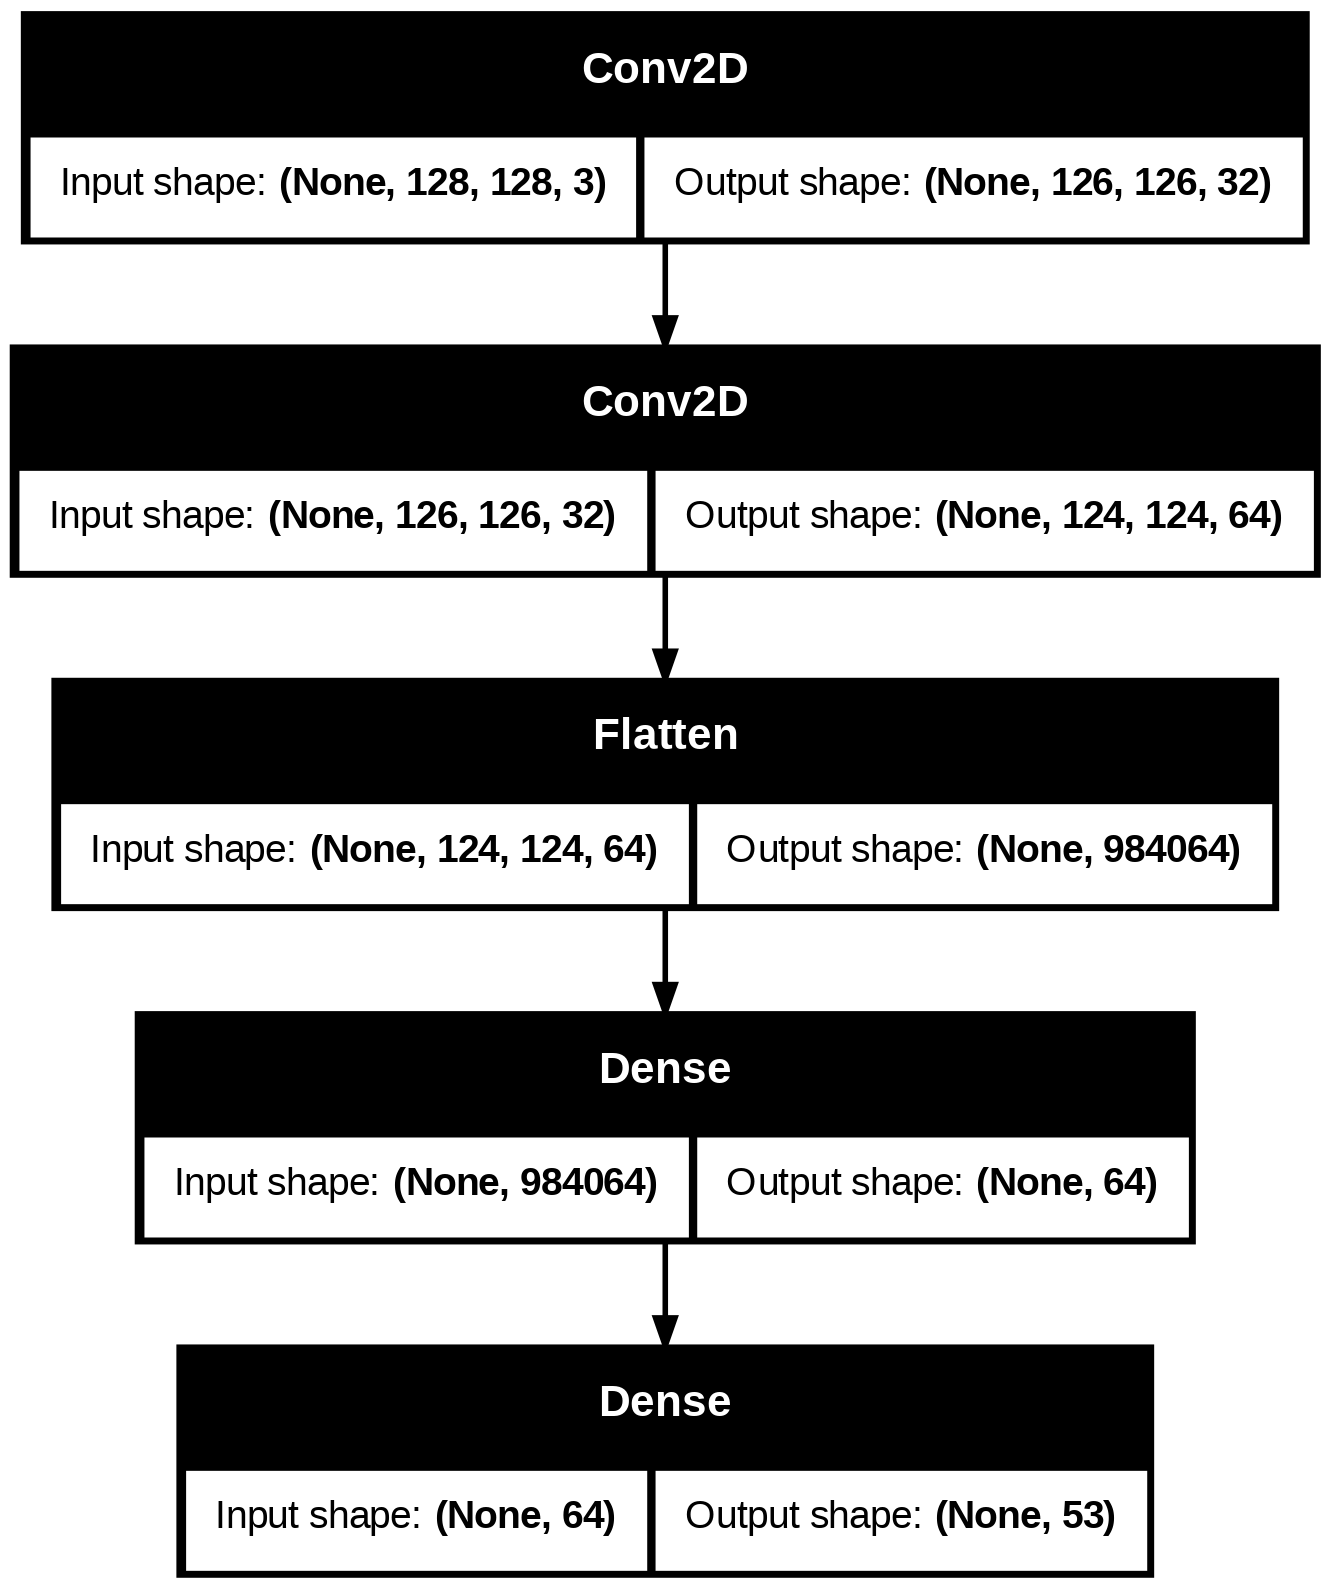

In [29]:
plot_model(model, show_shapes=True)